In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from cns.analyze.heatmap import fig_CN_heatmap
from cns.process.binning import bin_block
from cns.utils.selection import cns_head
from cns.utils.assemblies import hg19
from cns.data_utils import docs_path, out_path, load_cns_out

# auto reload modules
%load_ext autoreload
%autoreload 2

In [2]:
yticks = [-1, 0, 1, 2, 3]
# start a timer

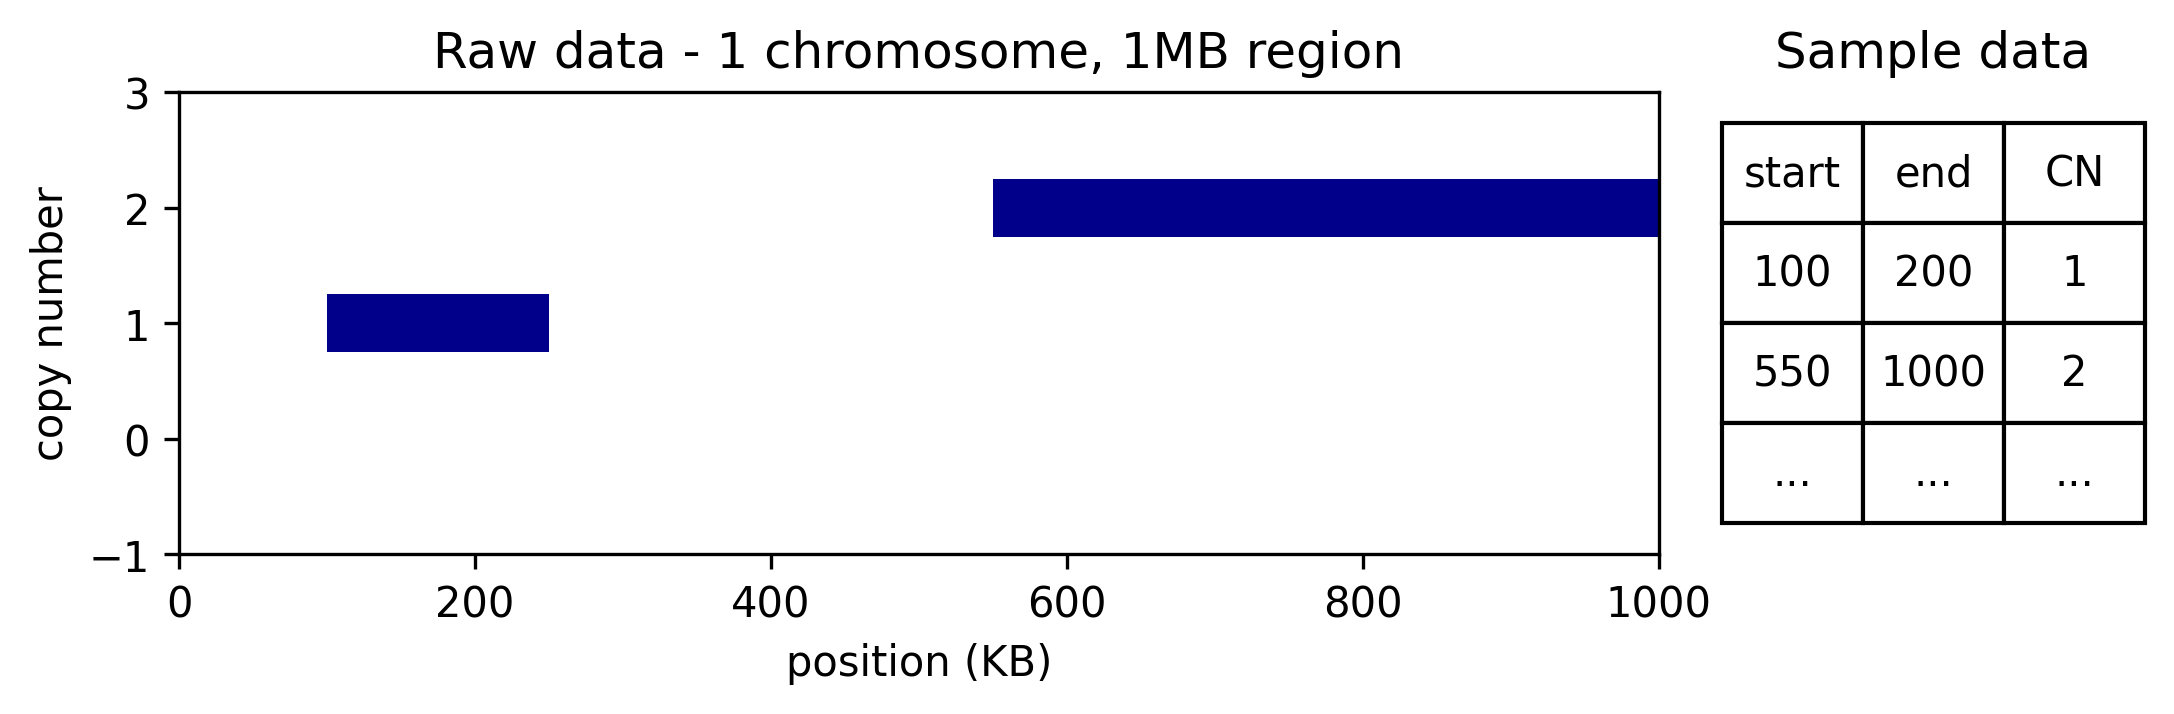

In [3]:
fig = plt.figure(figsize=(8, 2), dpi = 300)
gs = gridspec.GridSpec(1, 2, width_ratios=[7, 1])

# Create the first subplot for the plot
ax0 = plt.subplot(gs[0])

# Add horizontal bars
ax0.barh([1, 2], [150, 450], left=[100, 550], height=0.5, color='darkblue')

# Set the limits of the x-axis
ax0.set_xlim(0, 1000)

ax0.set_yticks(yticks)

# label
ax0.set_title('Raw data - 1 chromosome, 1MB region')
ax0.set_xlabel('position (KB)')
ax0.set_ylabel('copy number')

ax1 = plt.subplot(gs[1])

# Your data
data = [[100, 200, 1], [550, 1000, 2], ["...", "...", "..."]]

# Hide axes
ax1.axis('tight')
ax1.axis('off')
ax1.set_title("Sample data", loc='center')
# Add a table at the right of the axes
table = ax1.table(cellText=data, colLabels=["start", "end", "CN"], cellLoc = 'center', loc='center')
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(2, 2)

fig.savefig(f'{docs_path}/example_data.pdf', transparent=True, bbox_inches='tight')

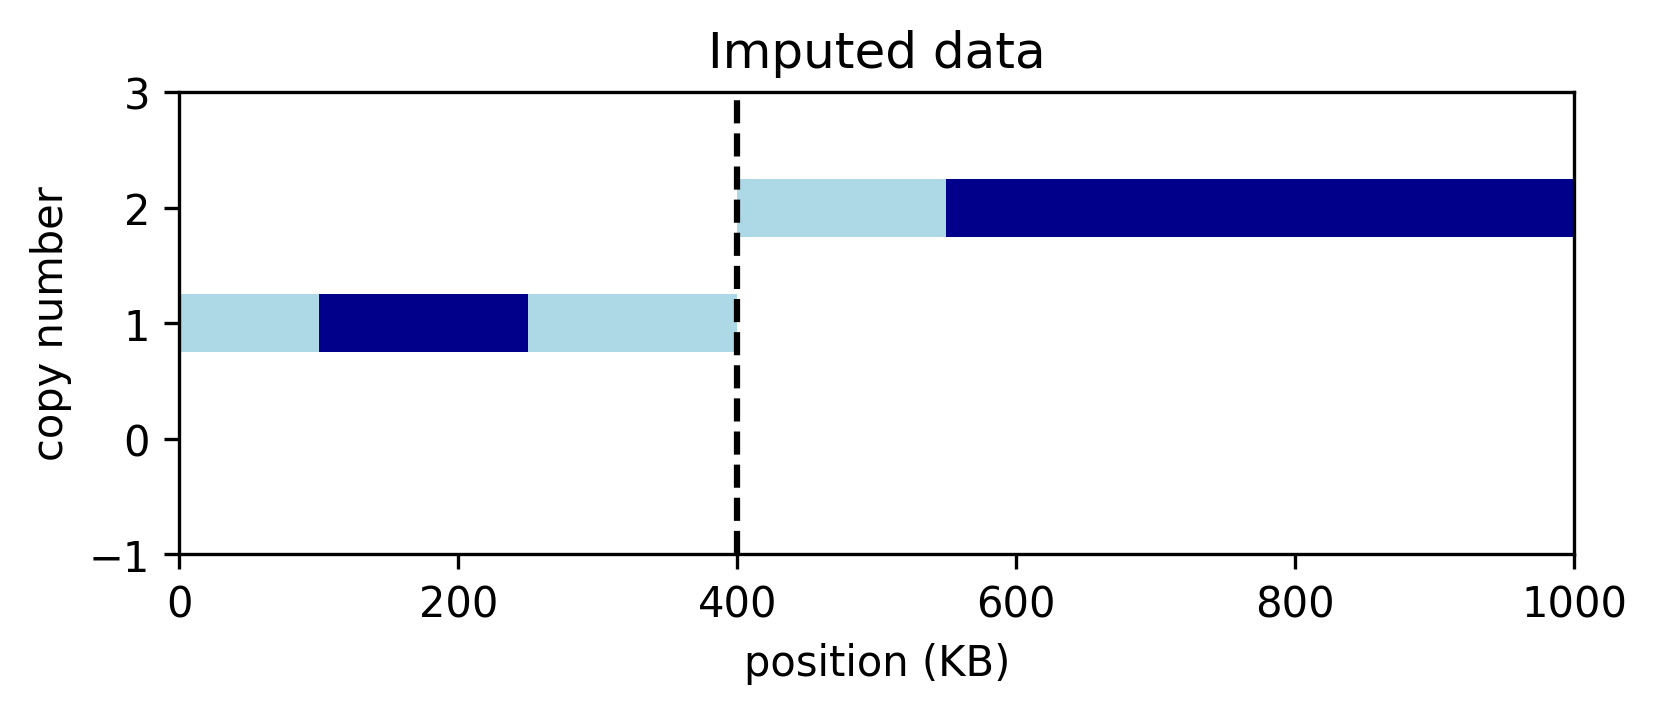

In [4]:
# Create a new figure
fig, ax = plt.subplots(1, 1, figsize=(6, 2), dpi=300)

# Add horizontal bars
plt.barh([1, 2], [150, 450], left=[100, 550], height=0.5, color='darkblue')
plt.barh([1, 1, 2], [100, 150, 150], left=[0, 250, 400], height=0.5, color='lightblue')
# add vertical line at 400
plt.axvline(x=400, color='k', linestyle='--')

# Set the limits of the x-axis
plt.xlim(0, 1000)

plt.yticks(yticks)

# label
plt.title('Imputed data')
plt.xlabel('position (KB)')
plt.ylabel('copy number')


fig.savefig(f'{docs_path}/example_impute.pdf', transparent=True, bbox_inches='tight')

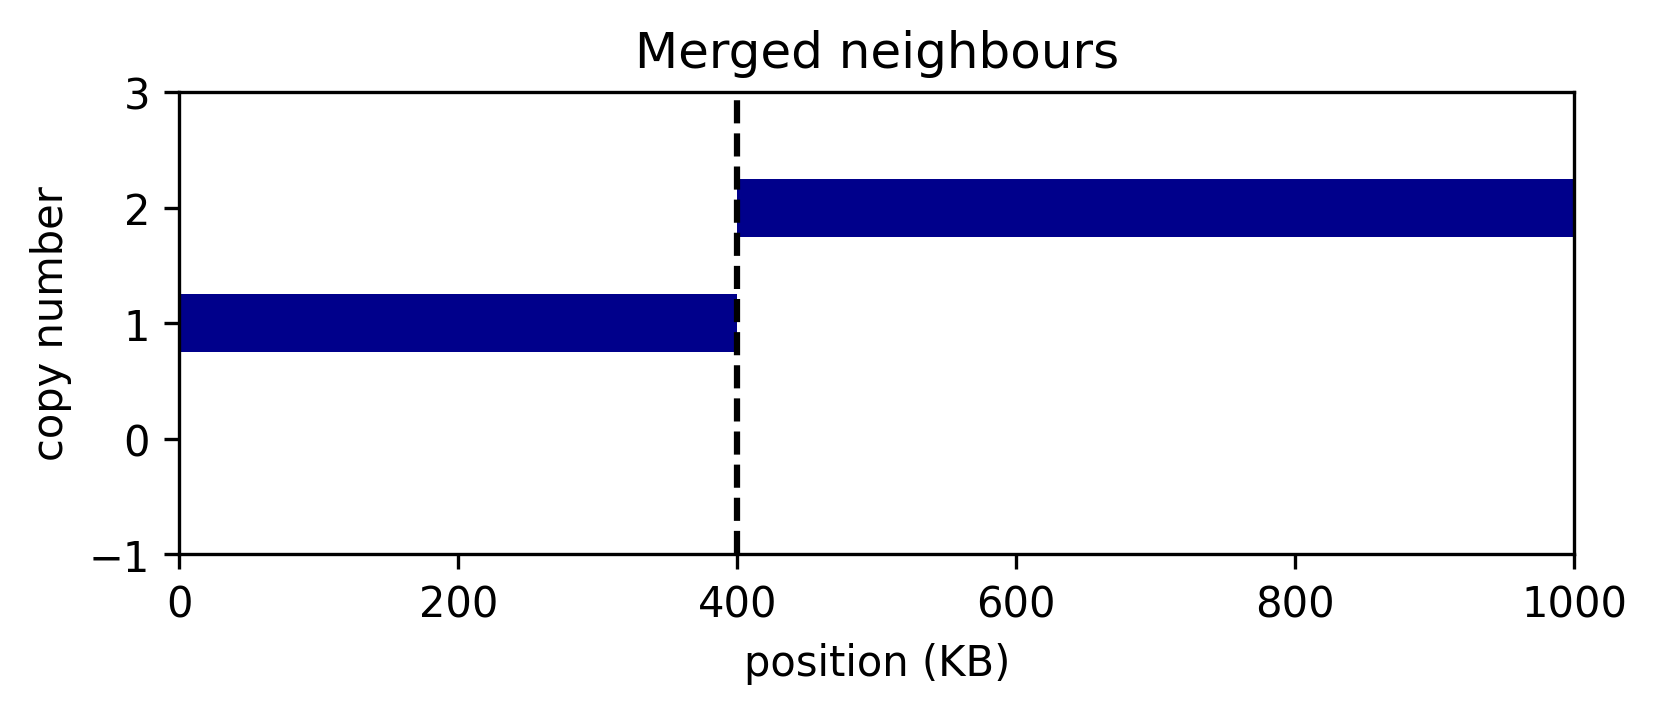

In [5]:
# Create a new figure
fig, ax = plt.subplots(1, 1, figsize=(6, 2), dpi=300)

# Add horizontal bars
plt.barh([1, 2], [150, 450], left=[100, 550], height=0.5, color='darkblue')
plt.barh([1, 1, 2], [100, 150, 150], left=[0, 250, 400], height=0.5, color='darkblue')
# add vertical line at 400
plt.axvline(x=400, color='k', linestyle='--')

# Set the limits of the x-axis
plt.xlim(0, 1000)

plt.yticks(yticks)

# label
plt.title('Merged neighbours')
plt.xlabel('position (KB)')
plt.ylabel('copy number')


fig.savefig(f'{docs_path}/example_merge.pdf', transparent=True, bbox_inches='tight')

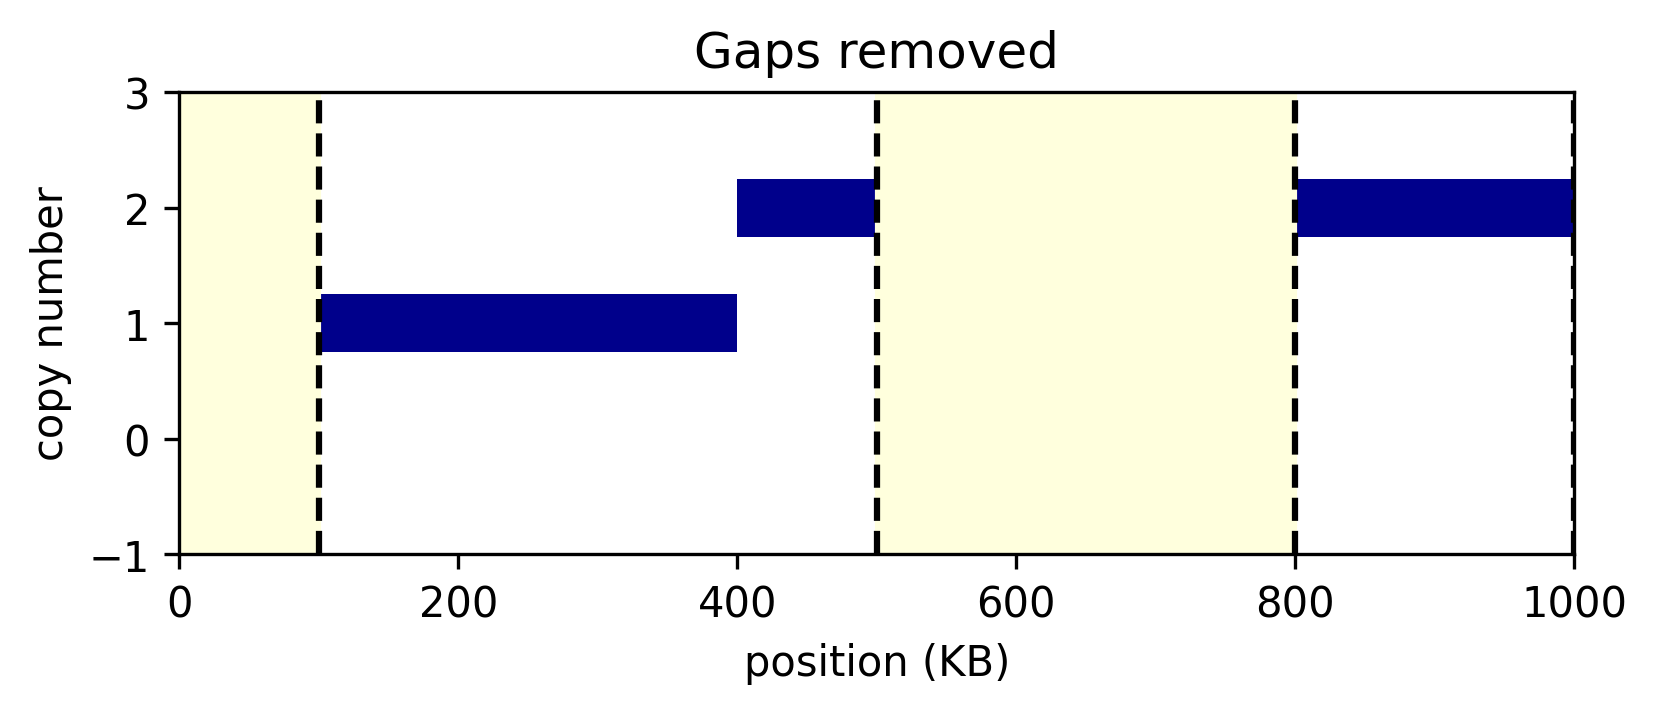

In [6]:
# Create a new figure
fig, ax = plt.subplots(1, 1, figsize=(6, 2), dpi=300)

# Add horizontal bars
plt.barh([1, 2], [150, 450], left=[100, 550], height=0.5, color='darkblue')
plt.barh([1, 1, 2], [100, 150, 150], left=[0, 250, 400], height=0.5, color='darkblue')

# add a square on -1 < t < 3 and 0 < x < 100
plt.fill_between([0, 100], -2, 4, color='#FFFFDD', alpha=1)
plt.fill_between([500, 800], -2, 4, color='#FFFFDD', alpha=1)

plt.axvline(x=100, color='k', linestyle='--')
plt.axvline(x=500, color='k', linestyle='--')
plt.axvline(x=800, color='k', linestyle='--')
plt.axvline(x=1000, color='k', linestyle='--')

# Set the limits of the x-axis
plt.xlim(0, 1000)
plt.ylim(-.5, 2.5)

plt.yticks(yticks)

# label
plt.title('Gaps removed')
plt.xlabel('position (KB)')
plt.ylabel('copy number')


fig.savefig(f'{docs_path}/example_gaps.pdf', transparent=True, bbox_inches='tight')

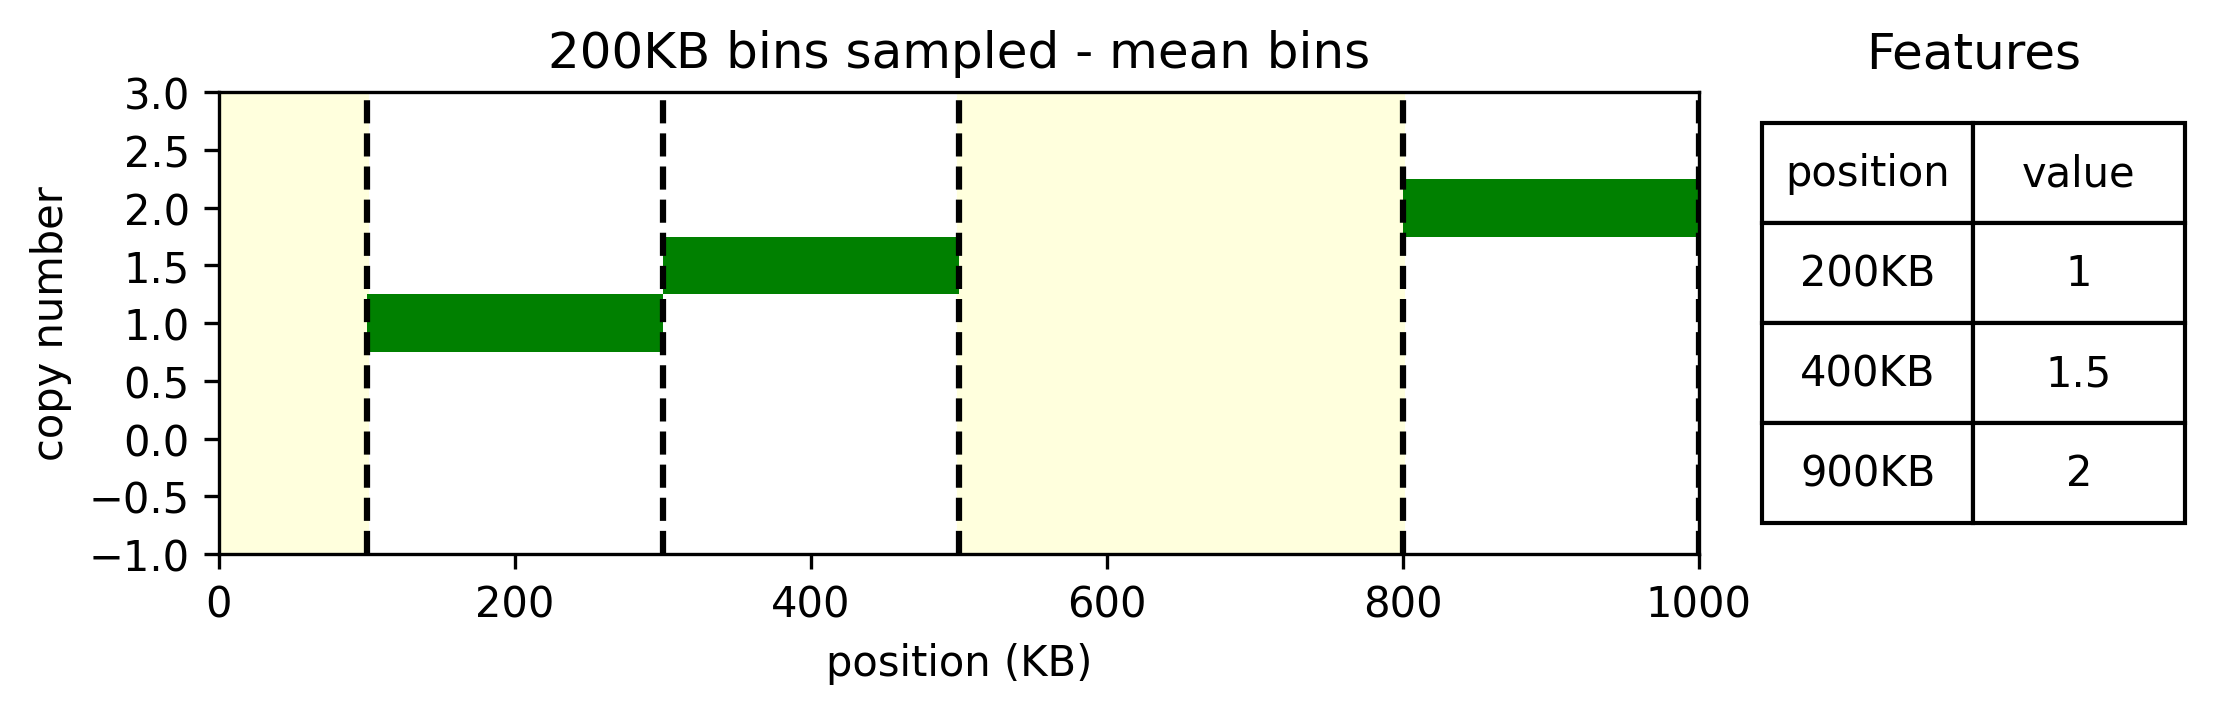

In [7]:
# Create a grid of 1 row and 2 columns
fig = plt.figure(figsize=(8, 2), dpi = 300)
gs = gridspec.GridSpec(1, 2, width_ratios=[7, 1])

# Create the first subplot for the plot
ax0 = plt.subplot(gs[0])

# add a square on -1 < t < 3 and 0 < x < 100
ax0.fill_between([0, 100], -2, 4, color='#FFFFDD', alpha=1)
ax0.fill_between([500, 800], -2, 4, color='#FFFFDD', alpha=1)

# Add horizontal bars
ax0.barh([1], [200], left=[100], height=0.5, color='green')
ax0.barh([1.5], [200], left=[300], height=0.5, color='green')
ax0.barh([2], [200], left=[800], height=0.5, color='green')

ax0.axvline(x=100, color='k', linestyle='--')
ax0.axvline(x=300, color='k', linestyle='--')
ax0.axvline(x=500, color='k', linestyle='--')
ax0.axvline(x=800, color='k', linestyle='--')
ax0.axvline(x=1000, color='k', linestyle='--')

# Set the limits of the x-axis
ax0.set_xlim(0, 1000)
ax0.set_ylim(-.5, 2.5)

ax0.set_yticks([-1, -.5, 0, .5, 1, 1.5, 2, 2.5, 3])

# label
ax0.set_title('200KB bins sampled - mean bins')
ax0.set_xlabel('position (KB)')
ax0.set_ylabel('copy number')

# Create the second subplot for the table
ax1 = plt.subplot(gs[1])

# Your data
data = [["200KB", 1], ["400KB", 1.5], ["900KB", 2]]

# Hide axes
ax1.axis('tight')
ax1.axis('off')
ax1.set_title("Features", loc='center')
# Add a table at the right of the axes
table = ax1.table(cellText=data, colLabels=["position", "value"], cellLoc = 'center', loc='center')
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(2, 2)

fig.savefig(f'{docs_path}/example_bins.pdf', transparent=True, bbox_inches='tight')

Binning chr (277/277)


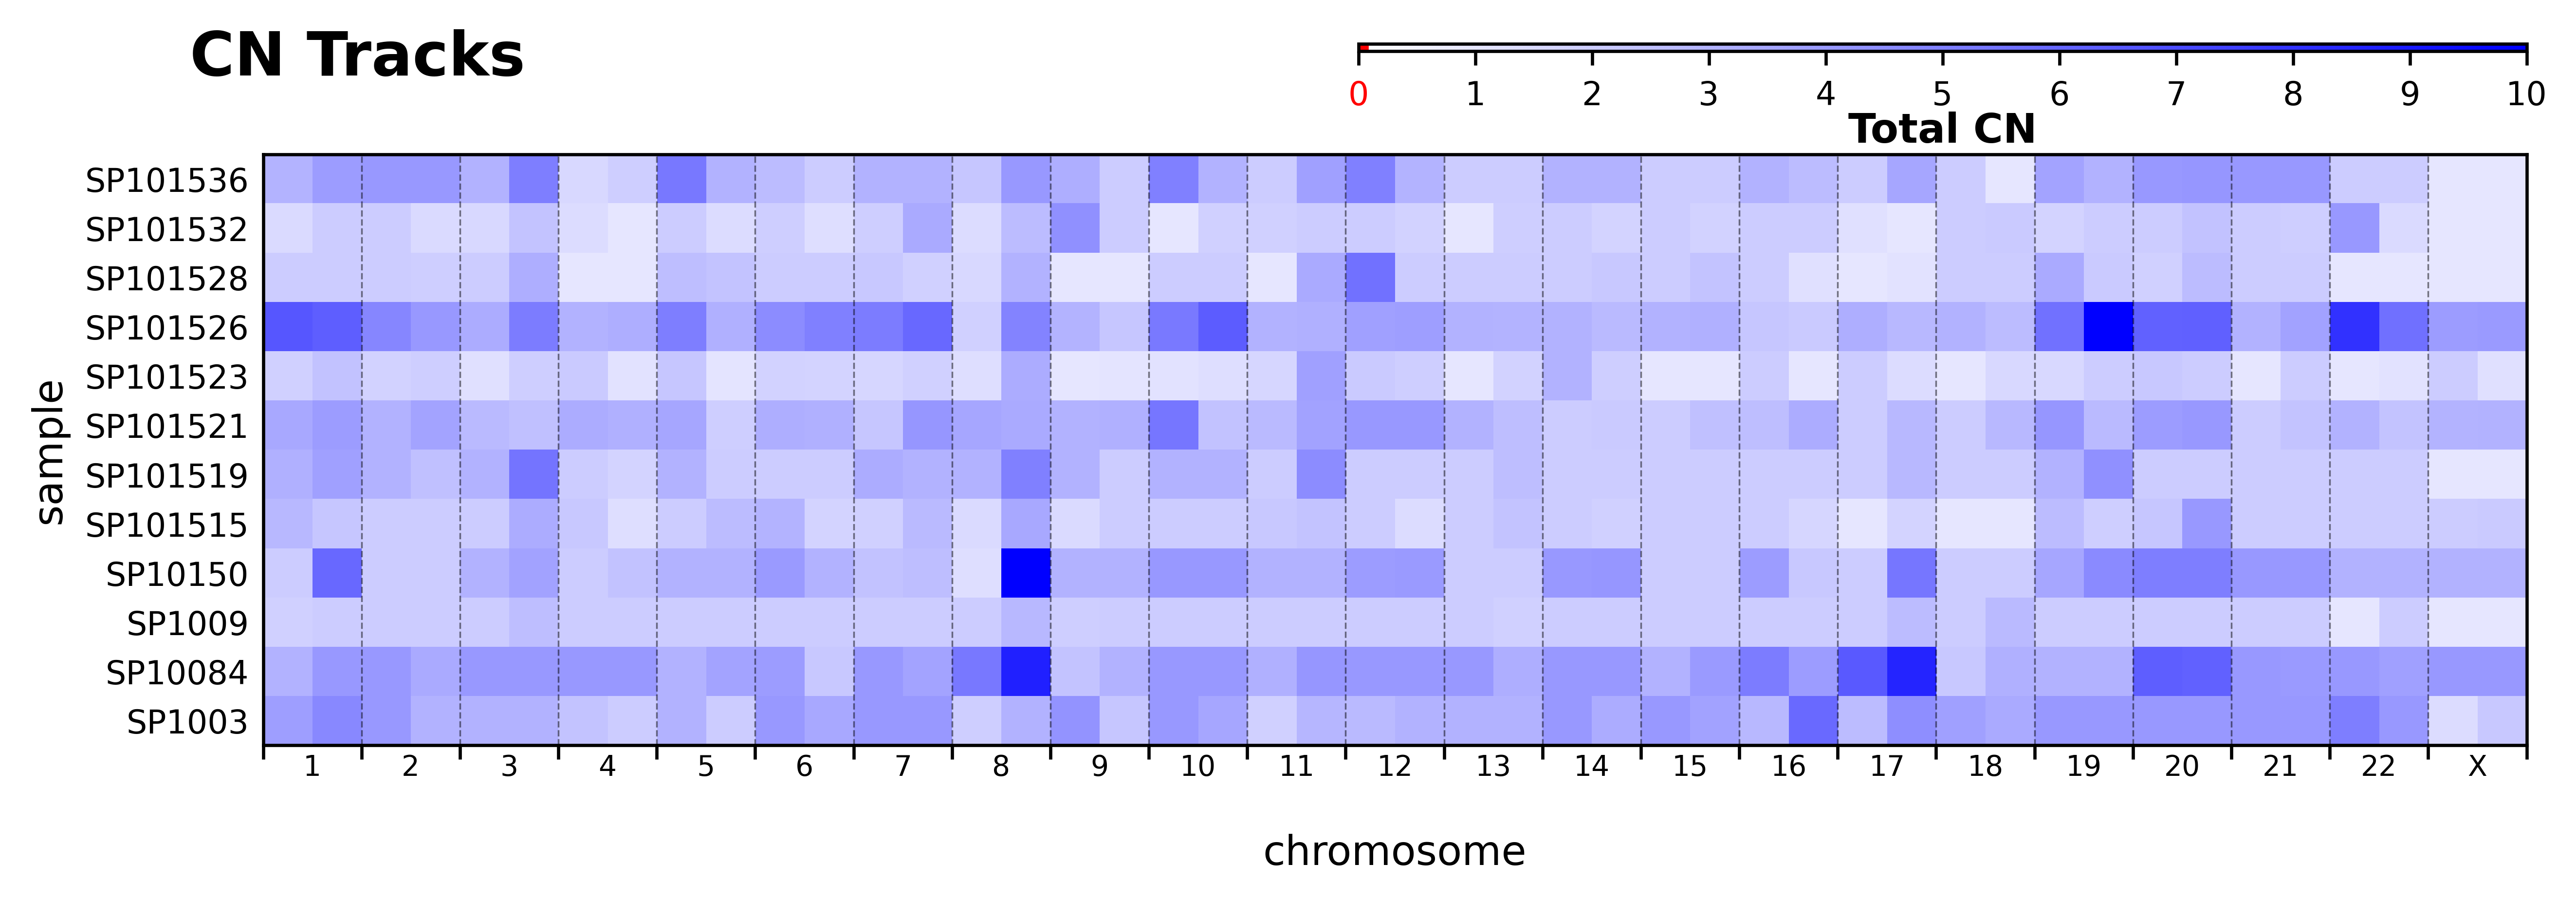

In [8]:
pcawg_cns_df = load_cns_out("PCAWG_cns_imp.tsv")
subset_arms = bin_block(cns_head(pcawg_cns_df, 12), "arms", hg19)
subset_arms = subset_arms[subset_arms["chrom"] != "chrY"]
fig_CN_heatmap(subset_arms, width=10, dpi=600, vertical_legend_correction=0.02)
plt.savefig(f'{docs_path}/example_heatmap.pdf', transparent=True, bbox_inches='tight')